# 🧠 Customer Churn Prediction - Student Practice Notebook
Welcome to the customer churn prediction notebook. In this exercise, you'll explore data about customer behavior and build a model to predict whether a customer will leave (churn) or stay.

## 📁 1. Load the Dataset

In [1]:
import pandas as pd

In [2]:
# Load the dataset
df = pd.read_csv("/content/customer_Leave_or_Stay.csv")

## 🔍 2. Dataset Overview
Understand the structure and types of data you're working with.

In [3]:
print(df.shape)
print(df.info())
print(df.head())
print(df.describe())
df.isnull().sum()

(10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0  

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


## 📊 3. Exploratory Data Analysis (EDA)

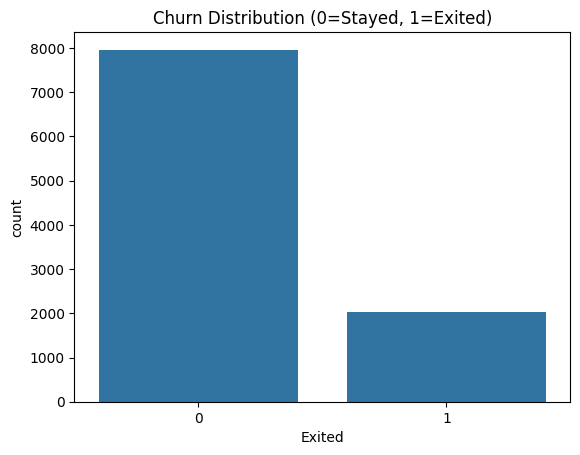

In [4]:
# Visualize key relationships and distributions.
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='Exited', data=df)
plt.title('Churn Distribution (0=Stayed, 1=Exited)')
plt.show()

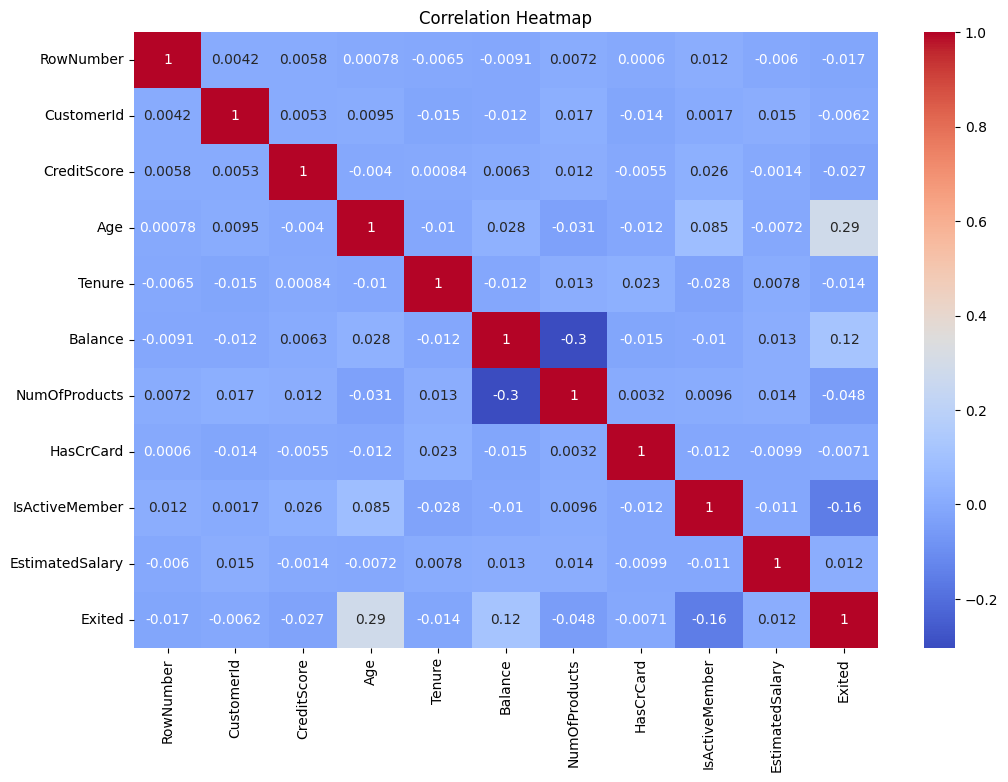

In [5]:

# Correlation heatmap (for numeric columns)
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 🧼 4. Data Preprocessing

Clean the data and prepare it for training.

In [6]:
from sklearn.preprocessing import LabelEncoder
# Convert categorical variables to dummy/label encoded
le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])

df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# Handle missing values
df.isnull().sum()

# Drop irrelevant features (like customer IDs, names, etc.)
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

## ✂️ 5. Train-Test Split
Separate your data into features and target, then split into training and test sets.

In [7]:
from sklearn.model_selection import train_test_split
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 🧠 6. Model Training (Logistic Regression)
Train a simple model to start with.

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

## 📏 7. Model Evaluation
Check how well your model performs.

Accuracy Score: 0.8005

Confusion Matrix:
 [[1567   40]
 [ 359   34]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.98      0.89      1607
           1       0.46      0.09      0.15       393

    accuracy                           0.80      2000
   macro avg       0.64      0.53      0.52      2000
weighted avg       0.74      0.80      0.74      2000



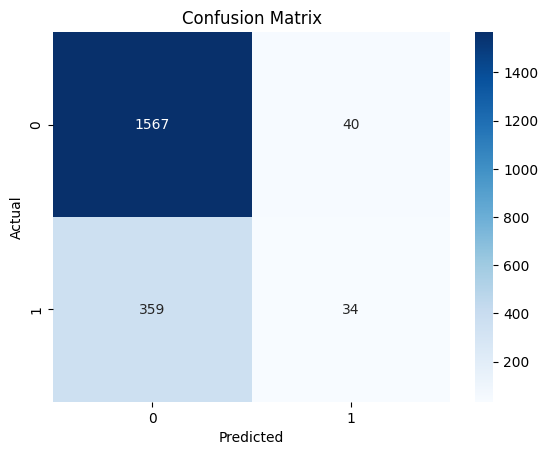

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
y_pred = model.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 📚 8. Student Exercises
Try solving these on your own:

Visualize how features like CreditScore, Balance, or Age affect churn.

Try using a different model (e.g., RandomForestClassifier).

Tune hyperparameters for better accuracy.

Use GridSearchCV or cross_val_score for model validation.

Try feature scaling using StandardScaler.

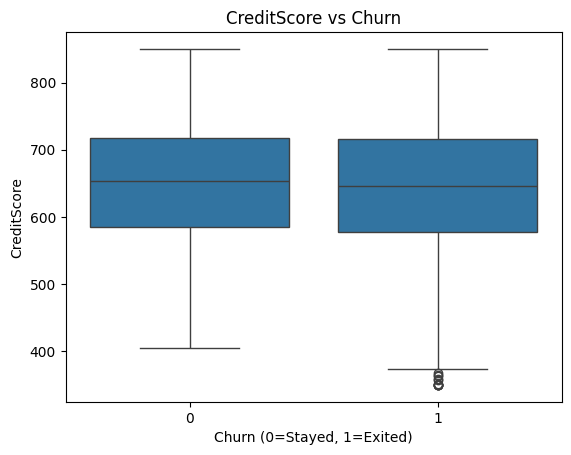

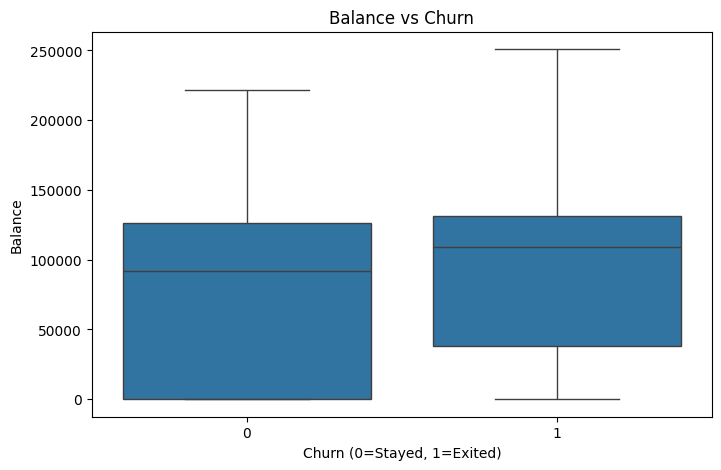

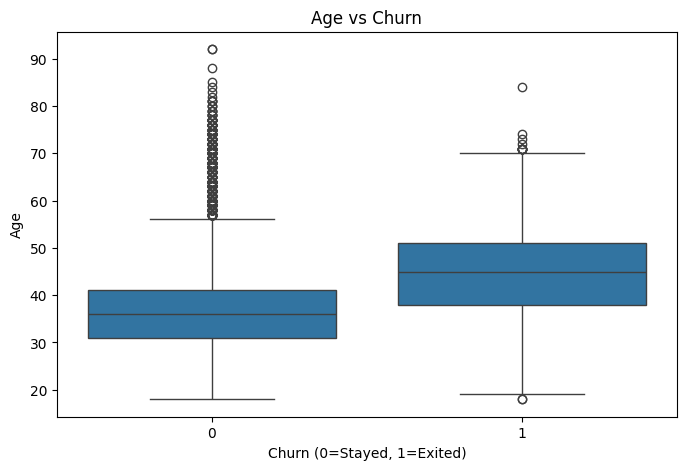

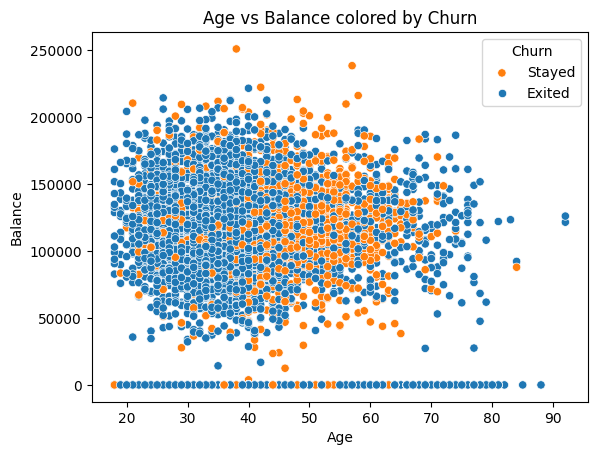

In [10]:
#Try solving these on your own:

#Visualize how features like CreditScore, Balance, or Age affect churn.
sns.boxplot(x='Exited', y='CreditScore', data=df)
plt.title('CreditScore vs Churn')
plt.xlabel('Churn (0=Stayed, 1=Exited)')
plt.ylabel('CreditScore')
plt.show()

#Balance vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='Exited', y='Balance', data=df)
plt.title('Balance vs Churn')
plt.xlabel('Churn (0=Stayed, 1=Exited)')
plt.ylabel('Balance')
plt.show()

#Age vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='Exited', y='Age', data=df)
plt.title('Age vs Churn')
plt.xlabel('Churn (0=Stayed, 1=Exited)')
plt.ylabel('Age')
plt.show()
#Age vs Balance by Churn
sns.scatterplot(x='Age', y='Balance', hue='Exited', data=df)
plt.title('Age vs Balance colored by Churn')
plt.xlabel('Age')
plt.ylabel('Balance')
plt.legend(title='Churn', labels=['Stayed', 'Exited'])
plt.show()



In [11]:
#Try using a different model (e.g., RandomForestClassifier).
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Accuracy: 0.866


In [12]:
#Tune hyperparameters for better accuracy.
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best GridSearch Accuracy:", grid_search.best_score_)



Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Best GridSearch Accuracy: 0.8656244957377326


In [13]:
#Use GridSearchCV or cross_val_score for model validation.
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross-validation scores: [0.7915 0.7925 0.7935 0.791  0.7855]
Mean CV accuracy: 0.7908


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [14]:
#Try feature scaling using StandardScaler.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
model_scaled = LogisticRegression(max_iter=1000, random_state=42)
model_scaled.fit(X_train, y_train)
y_pred_scaled = model_scaled.predict(X_test)
print("Scaled Accuracy:", accuracy_score(y_test, y_pred_scaled))
print("Classification Report:\n", classification_report(y_test, y_pred_scaled))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_scaled))

Scaled Accuracy: 0.811
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

Confusion Matrix:
 [[1543   64]
 [ 314   79]]


please note gives warning if not scaled, scaled later for comparison
(not an error)